# Strict baseline vs skeleton-junction fix

This notebook corrects the previous comparison. It uses the original `junction_ml_engineering_metrics.ipynb` data generation and baseline graph code, then adds exactly one new method: `skeleton_junction_fix`.

Important: **the baseline is called through the original `reconstruct_vectors_from_image(image, method="baseline")` path and is not changed.**

The skeletonization method deployed image pre-processing, which is a limitation for comparison

In [1]:
import random
import math
from pathlib import Path
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# New data every time by default.
SEED = None
if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

IMG_SIZE = 128
MAX_VECTORS = 5
LINE_WIDTH = 1

N_TRAIN_IMAGES = 600
N_TEST = 80

PATCH_SIZE = 9
PATCH_RADIUS = PATCH_SIZE // 2
JUNCTION_RADIUS = 2

BATCH_SIZE = 512
MLP_EPOCHS = 4
CNN_EPOCHS = 4
LEARNING_RATE = 1e-3

# Controls the final vector cleanup.
MIN_VECTOR_LENGTH = 2.0
MAX_MERGE_PASSES = 2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## Engineering drawing geometry configuration

These controls make the synthetic data and the final evaluation prefer engineering-style geometry: whole-degree angles, whole-pixel lengths, and stronger weighting for 90°, then 45°, 60°, 30°, and 10° angle families.


In [2]:
# Engineering drawing geometry controls
# These weights are deliberately easy to edit.
# A higher weight means mistakes on that angle family matter more, and data generation samples it more often.
GEOMETRY_CONFIG = {
    "angle_unit_deg": 1,          # all angles are rounded to whole degrees
    "length_unit_px": 1,          # all lengths are rounded to whole pixels
    "angle_unit_weights": {
        90: 5.0,                  # strongest preference: horizontal/vertical/right-angle work
        45: 3.0,
        60: 2.0,
        30: 1.5,
        10: 1.0,
        1: 0.25,                  # fallback: any whole-degree angle
    },
    "line_angle_tolerance_deg": 5.0,
    "junction_angle_tolerance_deg": 5.0,
    "length_tolerance_ratio": 0.15,
    "score_weights": {
        "line_geometry": 0.45,
        "total_length": 0.20,
        "junction_angles": 0.25,
        "vector_count": 0.10,
    },
}


def snap_angle_deg(angle_deg, unit_deg=None):
    """Snap an undirected line angle to the configured angle unit."""
    if unit_deg is None:
        unit_deg = GEOMETRY_CONFIG["angle_unit_deg"]
    return (round(angle_deg / unit_deg) * unit_deg) % 180


def snap_length_px(length_px, unit_px=None):
    """Snap a vector length to the configured pixel unit."""
    if unit_px is None:
        unit_px = GEOMETRY_CONFIG["length_unit_px"]
    return max(unit_px, round(length_px / unit_px) * unit_px)


def sample_weighted_angle_deg(config=GEOMETRY_CONFIG):
    """Sample a whole-degree engineering angle using the configured angle-family weights."""
    units = list(config["angle_unit_weights"].keys())
    weights = list(config["angle_unit_weights"].values())
    chosen_unit = random.choices(units, weights=weights, k=1)[0]

    # For line geometry, 0 and 180 degrees describe the same orientation.
    # We later add 180 randomly so the vector can point either way.
    if chosen_unit <= 1:
        base = random.randint(0, 179)
    else:
        candidates = list(range(0, 180, chosen_unit))
        base = random.choice(candidates)

    directed_angle = base + random.choice([0, 180])
    return round(directed_angle / config["angle_unit_deg"]) * config["angle_unit_deg"]


## 1. Synthetic vector data

Each sample has between 1 and 5 random straight lines. Lines are rasterised with 1-pixel weight on a white background.

(600, 128, 128) 600


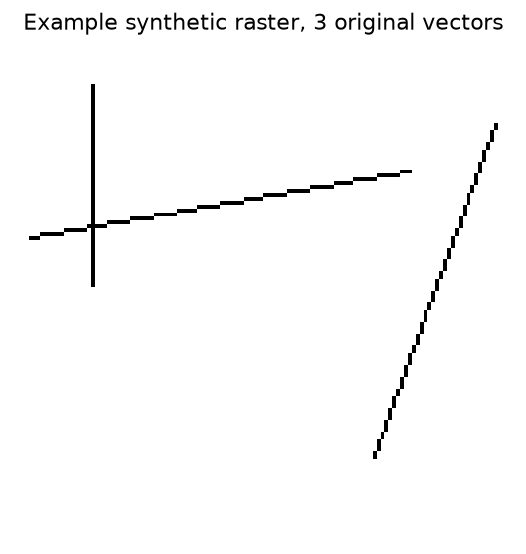

In [3]:
def clip_point(x, y, img_size=IMG_SIZE):
    return int(np.clip(round(x), 0, img_size - 1)), int(np.clip(round(y), 0, img_size - 1))


def bresenham_line(x0, y0, x1, y1):
    x0, y0, x1, y1 = map(int, [x0, y0, x1, y1])
    points = []
    dx = abs(x1 - x0)
    dy = -abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx + dy
    x, y = x0, y0
    while True:
        points.append((x, y))
        if x == x1 and y == y1:
            break
        e2 = 2 * err
        if e2 >= dy:
            err += dy
            x += sx
        if e2 <= dx:
            err += dx
            y += sy
    return points


def rasterise_vectors(vectors, img_size=IMG_SIZE):
    image = np.ones((img_size, img_size), dtype=np.float32)
    for x0, y0, x1, y1 in vectors:
        x0, y0 = clip_point(x0, y0, img_size)
        x1, y1 = clip_point(x1, y1, img_size)
        for x, y in bresenham_line(x0, y0, x1, y1):
            image[y, x] = 0.0
    return image


def random_line(img_size=IMG_SIZE, min_len=12, config=GEOMETRY_CONFIG):
    """Generate one engineering-style vector.

    The stored vector uses float endpoints so the intended length and angle are exact.
    Rasterisation still rounds endpoints to pixels when drawing the image.
    """
    margin = 4
    max_len = img_size - 12

    for _ in range(500):
        angle_deg = sample_weighted_angle_deg(config)
        angle_rad = math.radians(angle_deg)
        length = random.randint(min_len, max_len)
        length = snap_length_px(length, config["length_unit_px"])

        dx = math.cos(angle_rad) * length / 2
        dy = math.sin(angle_rad) * length / 2

        min_cx = margin + abs(dx)
        max_cx = img_size - 1 - margin - abs(dx)
        min_cy = margin + abs(dy)
        max_cy = img_size - 1 - margin - abs(dy)

        if min_cx > max_cx or min_cy > max_cy:
            continue

        cx = random.uniform(min_cx, max_cx)
        cy = random.uniform(min_cy, max_cy)

        x0, y0 = cx - dx, cy - dy
        x1, y1 = cx + dx, cy + dy

        if math.hypot(x1 - x0, y1 - y0) >= min_len:
            return (x0, y0, x1, y1)

    # fallback: a clean horizontal line
    return (10.0, 10.0, float(img_size - 10), 10.0)


def generate_sample(max_vectors=MAX_VECTORS, img_size=IMG_SIZE):
    n = random.randint(1, max_vectors)
    vectors = [random_line(img_size) for _ in range(n)]
    image = rasterise_vectors(vectors, img_size)
    return image, vectors


def generate_dataset(n_samples):
    images, vectors = [], []
    for _ in range(n_samples):
        img, vec = generate_sample()
        images.append(img)
        vectors.append(vec)
    return np.stack(images), vectors

train_images, train_vectors = generate_dataset(N_TRAIN_IMAGES)
test_images, test_vectors = generate_dataset(N_TEST)

print(train_images.shape, len(train_vectors))
plt.figure(figsize=(5, 5), dpi=130)
plt.imshow(train_images[0], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.title(f'Example synthetic raster, {len(train_vectors[0])} original vectors')
plt.axis('off')
plt.show()

## Original segment-intersection helper

Reused unchanged because the engineering junction-angle metric depends on it.

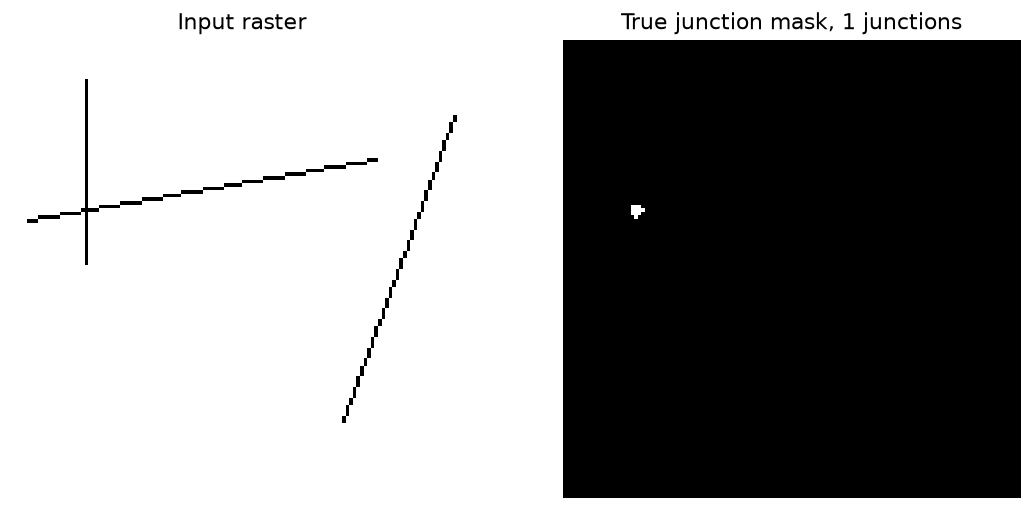

In [4]:
def segment_intersection(a, b, eps=1e-9):
    x1, y1, x2, y2 = map(float, a)
    x3, y3, x4, y4 = map(float, b)
    den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(den) < eps:
        return None
    px = ((x1*y2 - y1*x2) * (x3 - x4) - (x1 - x2) * (x3*y4 - y3*x4)) / den
    py = ((x1*y2 - y1*x2) * (y3 - y4) - (y1 - y2) * (x3*y4 - y3*x4)) / den

    def between(p, q, r):
        return min(p, r) - 1e-6 <= q <= max(p, r) + 1e-6

    if between(x1, px, x2) and between(y1, py, y2) and between(x3, px, x4) and between(y3, py, y4):
        return px, py
    return None


def junction_mask_from_vectors(vectors, img_size=IMG_SIZE, radius=JUNCTION_RADIUS):
    mask = np.zeros((img_size, img_size), dtype=np.float32)
    points = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is not None:
                points.append(p)
                cx, cy = p
                for y in range(max(0, int(cy - radius)), min(img_size, int(cy + radius) + 1)):
                    for x in range(max(0, int(cx - radius)), min(img_size, int(cx + radius) + 1)):
                        if (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2:
                            mask[y, x] = 1.0
    return mask, points

train_junction_masks = []
for vecs in train_vectors:
    m, _ = junction_mask_from_vectors(vecs)
    train_junction_masks.append(m)
train_junction_masks = np.stack(train_junction_masks)

sample_idx = 0
jm, pts = junction_mask_from_vectors(train_vectors[sample_idx])
fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=130)
ax[0].imshow(train_images[sample_idx], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[0].set_title('Input raster')
ax[1].imshow(jm, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
ax[1].set_title(f'True junction mask, {len(pts)} junctions')
for a in ax:
    a.axis('off')
plt.show()

## Original baseline helpers

These definitions keep the original baseline junction rule: `neighbour_count >= 3` followed by `expand_mask(radius=1)`. The MLP/CNN patch code is not used in this notebook because the comparison is baseline vs skeleton only.

In [5]:
def threshold_stroke(image):
    return (image <= 0.5).astype(np.uint8)


def neighbour_count(mask, y, x):
    h, w = mask.shape
    c = 0
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dx == 0 and dy == 0:
                continue
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and mask[yy, xx]:
                c += 1
    return c


def baseline_graph_junction_mask(image):
    # EXACT same rule as the original baseline: threshold -> neighbour_count >= 3 -> expand radius 1.
    stroke = threshold_stroke(image)
    out = np.zeros_like(stroke, dtype=np.uint8)
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if neighbour_count(stroke, y, x) >= 3:
            out[y, x] = 1
    return expand_mask(out, radius=1)


def expand_mask(mask, radius=1):
    out = mask.copy().astype(np.uint8)
    ys, xs = np.where(mask > 0)
    h, w = mask.shape
    for y, x in zip(ys, xs):
        for yy in range(max(0, y - radius), min(h, y + radius + 1)):
            for xx in range(max(0, x - radius), min(w, x + radius + 1)):
                if (yy - y) ** 2 + (xx - x) ** 2 <= radius ** 2:
                    out[yy, xx] = 1
    return out

## 6. Junction-aware vector reconstruction

This is the key change. Instead of creating many tiny line pieces inside a junction cluster, the algorithm contracts each predicted junction region to a single node and traces arms out from it.

This gives a middle ground:

- it does not delete the junction, so gaps are reduced;
- it does not fit many tiny lines inside the junction, so visual clutter is reduced.

In [6]:
NEIGHBOURS_8 = [
    (-1, -1), (0, -1), (1, -1),
    (-1,  0),          (1,  0),
    (-1,  1), (0,  1), (1,  1),
]


def connected_components(mask):
    mask = mask.astype(bool)
    h, w = mask.shape
    seen = np.zeros_like(mask, dtype=bool)
    comps = []
    for y in range(h):
        for x in range(w):
            if not mask[y, x] or seen[y, x]:
                continue
            q = deque([(y, x)])
            seen[y, x] = True
            comp = []
            while q:
                cy, cx = q.popleft()
                comp.append((cy, cx))
                for dx, dy in NEIGHBOURS_8:
                    ny, nx = cy + dy, cx + dx
                    if 0 <= ny < h and 0 <= nx < w and mask[ny, nx] and not seen[ny, nx]:
                        seen[ny, nx] = True
                        q.append((ny, nx))
            comps.append(comp)
    return comps


def make_node_map(stroke, junction_mask):
    h, w = stroke.shape
    node_map = -np.ones((h, w), dtype=np.int32)
    nodes = []

    # Junction nodes from connected predicted junction regions.
    for comp in connected_components(junction_mask & stroke):
        if len(comp) == 0:
            continue
        ys = np.array([p[0] for p in comp], dtype=np.float32)
        xs = np.array([p[1] for p in comp], dtype=np.float32)
        node_id = len(nodes)
        nodes.append({'type': 'junction', 'x': float(xs.mean()), 'y': float(ys.mean()), 'pixels': comp})
        for y, x in comp:
            node_map[y, x] = node_id

    # Endpoint nodes: stroke pixels with exactly one neighbour and not already in a junction.
    ys, xs = np.where(stroke == 1)
    for y, x in zip(ys, xs):
        if node_map[y, x] >= 0:
            continue
        if neighbour_count(stroke, y, x) <= 1:
            node_id = len(nodes)
            nodes.append({'type': 'endpoint', 'x': float(x), 'y': float(y), 'pixels': [(y, x)]})
            node_map[y, x] = node_id
    return nodes, node_map


def distance_point_to_line(px, py, ax, ay, bx, by):
    vx, vy = bx - ax, by - ay
    wx, wy = px - ax, py - ay
    denom = vx * vx + vy * vy
    if denom == 0:
        return math.hypot(px - ax, py - ay)
    t = max(0.0, min(1.0, (wx * vx + wy * vy) / denom))
    qx, qy = ax + t * vx, ay + t * vy
    return math.hypot(px - qx, py - qy)


def fit_line_to_path(path_points):
    if len(path_points) < 2:
        return None
    pts = np.array([(x, y) for y, x in path_points], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def line_length(line):
    x0, y0, x1, y1 = line
    return math.hypot(x1 - x0, y1 - y0)


def trace_vectors_with_junctions(image, junction_mask):
    stroke = threshold_stroke(image)
    nodes, node_map = make_node_map(stroke, junction_mask.astype(np.uint8))
    h, w = stroke.shape
    visited_edges = set()
    vectors = []
    paths = []

    def stroke_neighbours(y, x):
        out = []
        for dx, dy in NEIGHBOURS_8:
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and stroke[yy, xx]:
                out.append((yy, xx))
        return out

    # Start tracing from every node pixel to every adjacent non-node stroke pixel.
    for node_id, node in enumerate(nodes):
        for sy, sx in node['pixels']:
            for ny, nx in stroke_neighbours(sy, sx):
                if node_map[ny, nx] == node_id:
                    continue
                edge_key = tuple(sorted(((sy, sx), (ny, nx))))
                if edge_key in visited_edges:
                    continue

                path = [(sy, sx), (ny, nx)]
                visited_edges.add(edge_key)
                prev = (sy, sx)
                cur = (ny, nx)
                end_node = node_map[cur]
                steps = 0

                while end_node < 0 and steps < IMG_SIZE * IMG_SIZE:
                    nbrs = stroke_neighbours(*cur)
                    # avoid immediately going backwards unless there is no choice
                    candidates = [p for p in nbrs if p != prev]
                    if not candidates:
                        break
                    # Prefer moving into a node; otherwise continue along the least-branching direction.
                    node_candidates = [p for p in candidates if node_map[p] >= 0]
                    if node_candidates:
                        nxt = node_candidates[0]
                    else:
                        unvisited = []
                        for p in candidates:
                            ek = tuple(sorted((cur, p)))
                            if ek not in visited_edges:
                                unvisited.append(p)
                        if not unvisited:
                            break
                        nxt = unvisited[0]

                    ek = tuple(sorted((cur, nxt)))
                    visited_edges.add(ek)
                    prev, cur = cur, nxt
                    path.append(cur)
                    end_node = node_map[cur]
                    steps += 1

                if len(path) >= 2:
                    # Use contracted node centres at either end when present.
                    start_id = node_id
                    end_id = node_map[path[-1]]
                    raw_line = fit_line_to_path(path)
                    if raw_line is None:
                        continue
                    x0, y0, x1, y1 = raw_line
                    if start_id >= 0:
                        x0, y0 = nodes[start_id]['x'], nodes[start_id]['y']
                    if end_id >= 0:
                        x1, y1 = nodes[end_id]['x'], nodes[end_id]['y']
                    line = (x0, y0, x1, y1)
                    if line_length(line) >= MIN_VECTOR_LENGTH:
                        vectors.append(line)
                        paths.append(path)

    debug = {
        'stroke': stroke,
        'junction_mask': junction_mask,
        'nodes': nodes,
        'node_map': node_map,
        'paths': paths,
    }
    return merge_collinear_vectors_fast(vectors), debug


def angle_of(line):
    x0, y0, x1, y1 = line
    return math.atan2(y1 - y0, x1 - x0)


def angle_diff(a, b):
    d = abs(a - b) % math.pi
    return min(d, math.pi - d)


def endpoint_distance(l1, l2):
    a = [(l1[0], l1[1]), (l1[2], l1[3])]
    b = [(l2[0], l2[1]), (l2[2], l2[3])]
    return min(math.hypot(x1-x2, y1-y2) for x1,y1 in a for x2,y2 in b)


def merged_line(l1, l2):
    pts = np.array([(l1[0], l1[1]), (l1[2], l1[3]), (l2[0], l2[1]), (l2[2], l2[3])], dtype=np.float32)
    cx, cy = pts.mean(axis=0)
    centered = pts - np.array([cx, cy])
    _, _, vh = np.linalg.svd(centered, full_matrices=False)
    direction = vh[0]
    t = centered @ direction
    p0 = np.array([cx, cy]) + direction * t.min()
    p1 = np.array([cx, cy]) + direction * t.max()
    return (float(p0[0]), float(p0[1]), float(p1[0]), float(p1[1]))


def merge_collinear_vectors_fast(vectors, angle_tol_deg=8, endpoint_tol=4):
    vectors = [v for v in vectors if line_length(v) >= MIN_VECTOR_LENGTH]
    angle_tol = math.radians(angle_tol_deg)
    for _ in range(MAX_MERGE_PASSES):
        used = [False] * len(vectors)
        new_vectors = []
        changed = False
        for i, vi in enumerate(vectors):
            if used[i]:
                continue
            current = vi
            used[i] = True
            for j in range(i + 1, len(vectors)):
                if used[j]:
                    continue
                vj = vectors[j]
                if angle_diff(angle_of(current), angle_of(vj)) <= angle_tol and endpoint_distance(current, vj) <= endpoint_tol:
                    current = merged_line(current, vj)
                    used[j] = True
                    changed = True
            if line_length(current) >= MIN_VECTOR_LENGTH:
                new_vectors.append(current)
        vectors = new_vectors
        if not changed:
            break
    return vectors


def reconstruct_vectors_from_image(image, method='baseline'):
    if method == 'baseline':
        jm = baseline_graph_junction_mask(image)
    elif method == 'mlp':
        jm = predict_junction_mask_mlp(image)
    elif method == 'cnn':
        jm = predict_junction_mask_cnn(image)
    else:
        raise ValueError('method must be baseline, mlp, or cnn')
    return trace_vectors_with_junctions(image, jm)

## New method: skeleton-junction fix

The baseline above is unchanged. This new method skeletonises the stroke mask, detects junctions on the skeleton, and then runs the same kind of node/path tracing on the skeleton.

In [7]:
# Skeleton-junction fix
# This is the only new vectorisation method in this notebook.
# It does NOT replace or alter the original baseline function above.

SKELETON_JUNCTION_EXPAND_RADIUS = 1


def skeletonize_zhang_suen(binary):
    """Pure NumPy Zhang-Suen thinning.

    Input:  1 = stroke, 0 = background
    Output: 1-pixel-wide skeleton, 1 = stroke

    This avoids changing your environment or requiring scikit-image.
    """
    img = (binary > 0).astype(np.uint8).copy()
    h, w = img.shape

    def neighbours(y, x):
        # P2, P3, ..., P9 around P1=(y,x), clockwise from north.
        return [
            img[y - 1, x],     # P2
            img[y - 1, x + 1], # P3
            img[y,     x + 1], # P4
            img[y + 1, x + 1], # P5
            img[y + 1, x],     # P6
            img[y + 1, x - 1], # P7
            img[y,     x - 1], # P8
            img[y - 1, x - 1], # P9
        ]

    changed = True
    while changed:
        changed = False

        for step in (0, 1):
            remove = []

            for y in range(1, h - 1):
                for x in range(1, w - 1):
                    if img[y, x] == 0:
                        continue

                    p = neighbours(y, x)
                    n = sum(p)
                    if n < 2 or n > 6:
                        continue

                    transitions = sum((p[i] == 0 and p[(i + 1) % 8] == 1) for i in range(8))
                    if transitions != 1:
                        continue

                    p2, p3, p4, p5, p6, p7, p8, p9 = p

                    if step == 0:
                        c1 = p2 * p4 * p6 == 0
                        c2 = p4 * p6 * p8 == 0
                    else:
                        c1 = p2 * p4 * p8 == 0
                        c2 = p2 * p6 * p8 == 0

                    if c1 and c2:
                        remove.append((y, x))

            if remove:
                for y, x in remove:
                    img[y, x] = 0
                changed = True

    return img.astype(np.uint8)


def skeleton_graph_junction_mask_from_stroke(skeleton):
    """Detect junction nodes on the skeleton using the same neighbour-count idea as baseline."""
    out = np.zeros_like(skeleton, dtype=np.uint8)
    ys, xs = np.where(skeleton == 1)
    for y, x in zip(ys, xs):
        if neighbour_count(skeleton, y, x) >= 3:
            out[y, x] = 1
    return expand_mask(out, radius=SKELETON_JUNCTION_EXPAND_RADIUS)


def trace_vectors_with_junctions_from_stroke(stroke, junction_mask):
    """Same tracing logic as trace_vectors_with_junctions(), but using a supplied stroke mask.

    The original baseline still calls trace_vectors_with_junctions(image, jm) unchanged.
    This helper exists only so the skeleton method can trace along the skeleton instead of the raw raster.
    """
    stroke = stroke.astype(np.uint8)
    nodes, node_map = make_node_map(stroke, junction_mask.astype(np.uint8))
    h, w = stroke.shape
    visited_edges = set()
    vectors = []
    paths = []

    def stroke_neighbours(y, x):
        out = []
        for dx, dy in NEIGHBOURS_8:
            yy, xx = y + dy, x + dx
            if 0 <= yy < h and 0 <= xx < w and stroke[yy, xx]:
                out.append((yy, xx))
        return out

    for node_id, node in enumerate(nodes):
        for sy, sx in node['pixels']:
            for ny, nx in stroke_neighbours(sy, sx):
                if node_map[ny, nx] == node_id:
                    continue
                edge_key = tuple(sorted(((sy, sx), (ny, nx))))
                if edge_key in visited_edges:
                    continue

                path = [(sy, sx), (ny, nx)]
                visited_edges.add(edge_key)
                prev = (sy, sx)
                cur = (ny, nx)
                end_node = node_map[cur]
                steps = 0

                while end_node < 0 and steps < IMG_SIZE * IMG_SIZE:
                    nbrs = stroke_neighbours(*cur)
                    candidates = [p for p in nbrs if p != prev]
                    if not candidates:
                        break

                    node_candidates = [p for p in candidates if node_map[p] >= 0]
                    if node_candidates:
                        nxt = node_candidates[0]
                    else:
                        unvisited = []
                        for p in candidates:
                            ek = tuple(sorted((cur, p)))
                            if ek not in visited_edges:
                                unvisited.append(p)
                        if not unvisited:
                            break
                        nxt = unvisited[0]

                    ek = tuple(sorted((cur, nxt)))
                    visited_edges.add(ek)
                    prev, cur = cur, nxt
                    path.append(cur)
                    end_node = node_map[cur]
                    steps += 1

                if len(path) >= 2:
                    start_id = node_id
                    end_id = node_map[path[-1]]
                    raw_line = fit_line_to_path(path)
                    if raw_line is None:
                        continue
                    x0, y0, x1, y1 = raw_line
                    if start_id >= 0:
                        x0, y0 = nodes[start_id]['x'], nodes[start_id]['y']
                    if end_id >= 0:
                        x1, y1 = nodes[end_id]['x'], nodes[end_id]['y']
                    line = (x0, y0, x1, y1)
                    if line_length(line) >= MIN_VECTOR_LENGTH:
                        vectors.append(line)
                        paths.append(path)

    debug = {
        'stroke': stroke,
        'junction_mask': junction_mask,
        'nodes': nodes,
        'node_map': node_map,
        'paths': paths,
    }
    return merge_collinear_vectors_fast(vectors), debug


def reconstruct_vectors_with_skeleton_junction_fix(image):
    raw_stroke = threshold_stroke(image)
    skeleton = skeletonize_zhang_suen(raw_stroke)
    jm = skeleton_graph_junction_mask_from_stroke(skeleton)
    vectors, debug = trace_vectors_with_junctions_from_stroke(skeleton, jm)
    debug['raw_stroke'] = raw_stroke
    debug['skeleton'] = skeleton
    debug['method'] = 'skeleton_junction_fix'
    return vectors, debug

## Original engineering metrics, reused

In [8]:
import pandas as pd
import numpy as np

METHODS = ["baseline", "mlp", "cnn"]


def raster_metrics(true_raster, pred_raster):
    """Pixel-overlap metrics are kept as a secondary check only."""
    true = true_raster < 0.5
    pred = pred_raster < 0.5

    tp = np.logical_and(true, pred).sum()
    fp = np.logical_and(~true, pred).sum()
    fn = np.logical_and(true, ~pred).sum()
    tn = np.logical_and(~true, ~pred).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-9)

    return precision, recall, f1, iou, accuracy


def vector_length_px(v):
    x0, y0, x1, y1 = v
    return math.hypot(x1 - x0, y1 - y0)


def vector_angle_deg(v, config=GEOMETRY_CONFIG):
    """Return an undirected snapped angle in degrees: 0 and 180 are equivalent."""
    x0, y0, x1, y1 = v
    angle = math.degrees(math.atan2(y1 - y0, x1 - x0)) % 180
    return snap_angle_deg(angle, config["angle_unit_deg"])


def angle_distance_deg(a, b):
    """Smallest distance between two undirected line angles."""
    d = abs(a - b) % 180
    return min(d, 180 - d)


def angle_family_importance(angle_deg, config=GEOMETRY_CONFIG):
    """Return a programmable importance weight for an angle.

    Example: 90-degree family angles are more important than arbitrary 1-degree angles.
    This does not change the geometry; it changes how strongly the metric cares about mistakes.
    """
    best = min(config["angle_unit_weights"].values())
    for unit, weight in config["angle_unit_weights"].items():
        if unit <= 1:
            continue
        nearest = round(angle_deg / unit) * unit
        err = angle_distance_deg(angle_deg, nearest)
        if err <= config["angle_unit_deg"] / 2 + 1e-9:
            best = max(best, weight)
    return best


def vector_count_score(true_vectors, pred_vectors):
    denom = max(len(true_vectors), len(pred_vectors), 1)
    return max(0.0, 1.0 - abs(len(true_vectors) - len(pred_vectors)) / denom)


def total_length_score(true_vectors, pred_vectors):
    true_total = sum(snap_length_px(vector_length_px(v)) for v in true_vectors)
    pred_total = sum(snap_length_px(vector_length_px(v)) for v in pred_vectors)
    denom = max(true_total, pred_total, 1e-9)
    return max(0.0, 1.0 - abs(true_total - pred_total) / denom)


def greedy_line_geometry_score(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    """Compare lines by length and angle, not by absolute endpoint location.

    This is the key metric for your goal: a 10x10 square translated slightly should still score well
    because its line lengths and line angles are right.
    """
    if len(true_vectors) == 0 and len(pred_vectors) == 0:
        return 1.0
    if len(true_vectors) == 0 or len(pred_vectors) == 0:
        return 0.0

    candidates = []
    for i, gt in enumerate(true_vectors):
        gt_len = snap_length_px(vector_length_px(gt), config["length_unit_px"])
        gt_ang = vector_angle_deg(gt, config)
        importance = angle_family_importance(gt_ang, config)

        for j, pred in enumerate(pred_vectors):
            pred_len = snap_length_px(vector_length_px(pred), config["length_unit_px"])
            pred_ang = vector_angle_deg(pred, config)

            angle_err = angle_distance_deg(gt_ang, pred_ang)
            length_err = abs(gt_len - pred_len)

            angle_part = max(0.0, 1.0 - angle_err / config["line_angle_tolerance_deg"])
            length_tol = max(config["length_unit_px"], config["length_tolerance_ratio"] * max(gt_len, 1.0))
            length_part = max(0.0, 1.0 - length_err / length_tol)

            pair_score = 0.65 * angle_part + 0.35 * length_part
            candidates.append((pair_score, importance, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    weighted_score = 0.0

    for pair_score, importance, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        weighted_score += pair_score * importance

    total_importance = sum(angle_family_importance(vector_angle_deg(v, config), config) for v in true_vectors)
    return weighted_score / max(total_importance, 1e-9)


def junction_angles_deg(vectors, config=GEOMETRY_CONFIG):
    """Return the acute angles at all places where two predicted/true segments meet or cross.

    This ignores the absolute location of the junction. It cares that the drawing contains the right
    kind of junctions, such as 90-degree corners in a square.
    """
    angles = []
    for i in range(len(vectors)):
        for j in range(i + 1, len(vectors)):
            p = segment_intersection(vectors[i], vectors[j])
            if p is None:
                continue
            a = vector_angle_deg(vectors[i], config)
            b = vector_angle_deg(vectors[j], config)
            d = angle_distance_deg(a, b)
            acute = min(d, 180 - d)
            if acute > 1e-6:
                angles.append(snap_angle_deg(acute, config["angle_unit_deg"]))
    return angles


def angle_list_score(true_angles, pred_angles, tolerance_deg):
    if len(true_angles) == 0 and len(pred_angles) == 0:
        return 1.0
    if len(true_angles) == 0 or len(pred_angles) == 0:
        return 0.0

    candidates = []
    for i, a in enumerate(true_angles):
        for j, b in enumerate(pred_angles):
            err = abs(a - b)
            score = max(0.0, 1.0 - err / tolerance_deg)
            candidates.append((score, i, j))

    candidates.sort(reverse=True, key=lambda x: x[0])
    used_true = set()
    used_pred = set()
    total = 0.0

    for score, i, j in candidates:
        if i in used_true or j in used_pred:
            continue
        used_true.add(i)
        used_pred.add(j)
        total += score

    return total / max(len(true_angles), len(pred_angles), 1)


def engineering_metrics(true_vectors, pred_vectors, config=GEOMETRY_CONFIG):
    line_geometry = greedy_line_geometry_score(true_vectors, pred_vectors, config)
    length_total = total_length_score(true_vectors, pred_vectors)
    count = vector_count_score(true_vectors, pred_vectors)

    true_junction_angles = junction_angles_deg(true_vectors, config)
    pred_junction_angles = junction_angles_deg(pred_vectors, config)
    junction_angles = angle_list_score(
        true_junction_angles,
        pred_junction_angles,
        config["junction_angle_tolerance_deg"],
    )

    w = config["score_weights"]
    engineering_score = (
        w["line_geometry"] * line_geometry
        + w["total_length"] * length_total
        + w["junction_angles"] * junction_angles
        + w["vector_count"] * count
    )

    return {
        "engineering_score": engineering_score,
        "line_geometry_score": line_geometry,
        "total_length_score": length_total,
        "junction_angle_score": junction_angles,
        "vector_count_score": count,
        "true_junctions": len(true_junction_angles),
        "pred_junctions": len(pred_junction_angles),
    }

## Compare exact original baseline against skeleton-junction fix

In [9]:
# Baseline vs skeleton-junction fix comparison.
# IMPORTANT: baseline is called through the original function with method='baseline'.

EXPORT_DIR = Path('strict_skeleton_junction_exports')
EXPORT_DIR.mkdir(exist_ok=True)

METHODS_TO_COMPARE = {
    'baseline_original_unchanged': lambda image: reconstruct_vectors_from_image(image, method='baseline'),
    'skeleton_junction_fix': reconstruct_vectors_with_skeleton_junction_fix,
}

comparison_outputs = {}
comparison_rows = []

for idx, (image, true_vectors) in enumerate(zip(test_images, test_vectors)):
    comparison_outputs[idx] = {}

    for method_name, method_fn in METHODS_TO_COMPARE.items():
        pred_vectors, debug = method_fn(image)
        comparison_outputs[idx][method_name] = {
            'vectors': pred_vectors,
            'debug': debug,
        }

        pred_raster = rasterise_vectors(pred_vectors, IMG_SIZE)
        precision, recall, f1, iou, pixel_accuracy = raster_metrics(image, pred_raster)
        geom = engineering_metrics(true_vectors, pred_vectors, GEOMETRY_CONFIG)

        comparison_rows.append({
            'method': method_name,
            'sample': idx,
            'true_vectors': len(true_vectors),
            'pred_vectors': len(pred_vectors),
            'vector_count_error': abs(len(true_vectors) - len(pred_vectors)),
            **geom,
            'pixel_precision': precision,
            'pixel_recall': recall,
            'pixel_f1': f1,
            'pixel_iou': iou,
            'pixel_accuracy': pixel_accuracy,
            'junction_nodes': len(debug.get('nodes', [])),
            'traced_paths': len(debug.get('paths', [])),
        })

comparison_df = pd.DataFrame(comparison_rows)
summary_df = (
    comparison_df
    .groupby('method')
    .mean(numeric_only=True)
    .sort_values('engineering_score', ascending=False)
    .round(4)
)

results_csv = EXPORT_DIR / 'baseline_original_vs_skeleton_junction_fix_results.csv'
summary_csv = EXPORT_DIR / 'baseline_original_vs_skeleton_junction_fix_summary.csv'
comparison_df.to_csv(results_csv, index=False)
summary_df.to_csv(summary_csv)

print('Data/constants intentionally kept from original notebook:')
print({
    'IMG_SIZE': IMG_SIZE,
    'MAX_VECTORS': MAX_VECTORS,
    'LINE_WIDTH': LINE_WIDTH,
    'N_TRAIN_IMAGES': N_TRAIN_IMAGES,
    'N_TEST': N_TEST,
    'PATCH_SIZE': PATCH_SIZE,
    'JUNCTION_RADIUS': JUNCTION_RADIUS,
    'MIN_VECTOR_LENGTH': MIN_VECTOR_LENGTH,
    'MAX_MERGE_PASSES': MAX_MERGE_PASSES,
})

print('\nAverage method comparison:')
display(summary_df)

print('\nFirst few per-sample rows:')
display(comparison_df.head(10))

print('\nSaved:')
print(results_csv)
print(summary_csv)

Data/constants intentionally kept from original notebook:
{'IMG_SIZE': 128, 'MAX_VECTORS': 5, 'LINE_WIDTH': 1, 'N_TRAIN_IMAGES': 600, 'N_TEST': 80, 'PATCH_SIZE': 9, 'JUNCTION_RADIUS': 2, 'MIN_VECTOR_LENGTH': 2.0, 'MAX_MERGE_PASSES': 2}

Average method comparison:


,sample,true_vectors,pred_vectors,vector_count_error,engineering_score,line_geometry_score,total_length_score,junction_angle_score,vector_count_score,true_junctions,pred_junctions,pixel_precision,pixel_recall,pixel_f1,pixel_iou,pixel_accuracy,junction_nodes,traced_paths
method,,,,,,,,,,,,,,,,,,
skeleton_junction_fix,39.5,3.05,3.1125,0.1125,0.9558,0.9712,0.9919,0.8893,0.9805,0.8,0.8000,0.9817,0.9759,0.9786,0.9637,0.9993,6.6750,4.4875
baseline_original_unchanged,39.5,3.05,3.1000,0.0750,0.9553,0.9672,0.9923,0.8907,0.9892,0.8,0.7875,0.9788,0.9739,0.9762,0.9625,0.9993,6.6625,4.4750



First few per-sample rows:


,method,sample,true_vectors,pred_vectors,vector_count_error,engineering_score,line_geometry_score,total_length_score,junction_angle_score,vector_count_score,true_junctions,pred_junctions,pixel_precision,pixel_recall,pixel_f1,pixel_iou,pixel_accuracy,junction_nodes,traced_paths
0,baseline_original_unchanged,0,1,1,0,1.000000,1.000000,1.000000,1.0,1.0,0,0,1.000000,1.000000,1.000000,1.000000,1.00000,2,1
1,skeleton_junction_fix,0,1,1,0,1.000000,1.000000,1.000000,1.0,1.0,0,0,1.000000,1.000000,1.000000,1.000000,1.00000,2,1
2,baseline_original_unchanged,1,2,2,0,1.000000,1.000000,1.000000,1.0,1.0,0,0,1.000000,1.000000,1.000000,1.000000,1.00000,4,2
3,skeleton_junction_fix,1,2,2,0,1.000000,1.000000,1.000000,1.0,1.0,0,0,1.000000,1.000000,1.000000,1.000000,1.00000,4,2
4,baseline_original_unchanged,2,3,3,0,0.987625,0.976989,0.989899,1.0,1.0,0,0,1.000000,1.000000,1.000000,1.000000,1.00000,6,4
5,skeleton_junction_fix,2,3,3,0,0.987625,0.976989,0.989899,1.0,1.0,0,0,1.000000,1.000000,1.000000,1.000000,1.00000,6,4
6,baseline_original_unchanged,3,5,5,0,0.998611,0.998426,0.996599,1.0,1.0,0,0,1.000000,1.000000,1.000000,1.000000,1.00000,10,5
7,skeleton_junction_fix,3,5,5,0,0.998611,0.998426,0.996599,1.0,1.0,0,0,1.000000,1.000000,1.000000,1.000000,1.00000,10,5
8,baseline_original_unchanged,4,5,5,0,0.980500,0.956667,1.000000,1.0,1.0,2,2,0.972376,0.972376,0.972376,0.946237,0.99939,12,9
9,skeleton_junction_fix,4,5,5,0,0.980500,0.956667,1.000000,1.0,1.0,2,2,0.972376,0.972376,0.972376,0.946237,0.99939,12,9



Saved:
strict_skeleton_junction_exports\baseline_original_vs_skeleton_junction_fix_results.csv
strict_skeleton_junction_exports\baseline_original_vs_skeleton_junction_fix_summary.csv


## Visual check

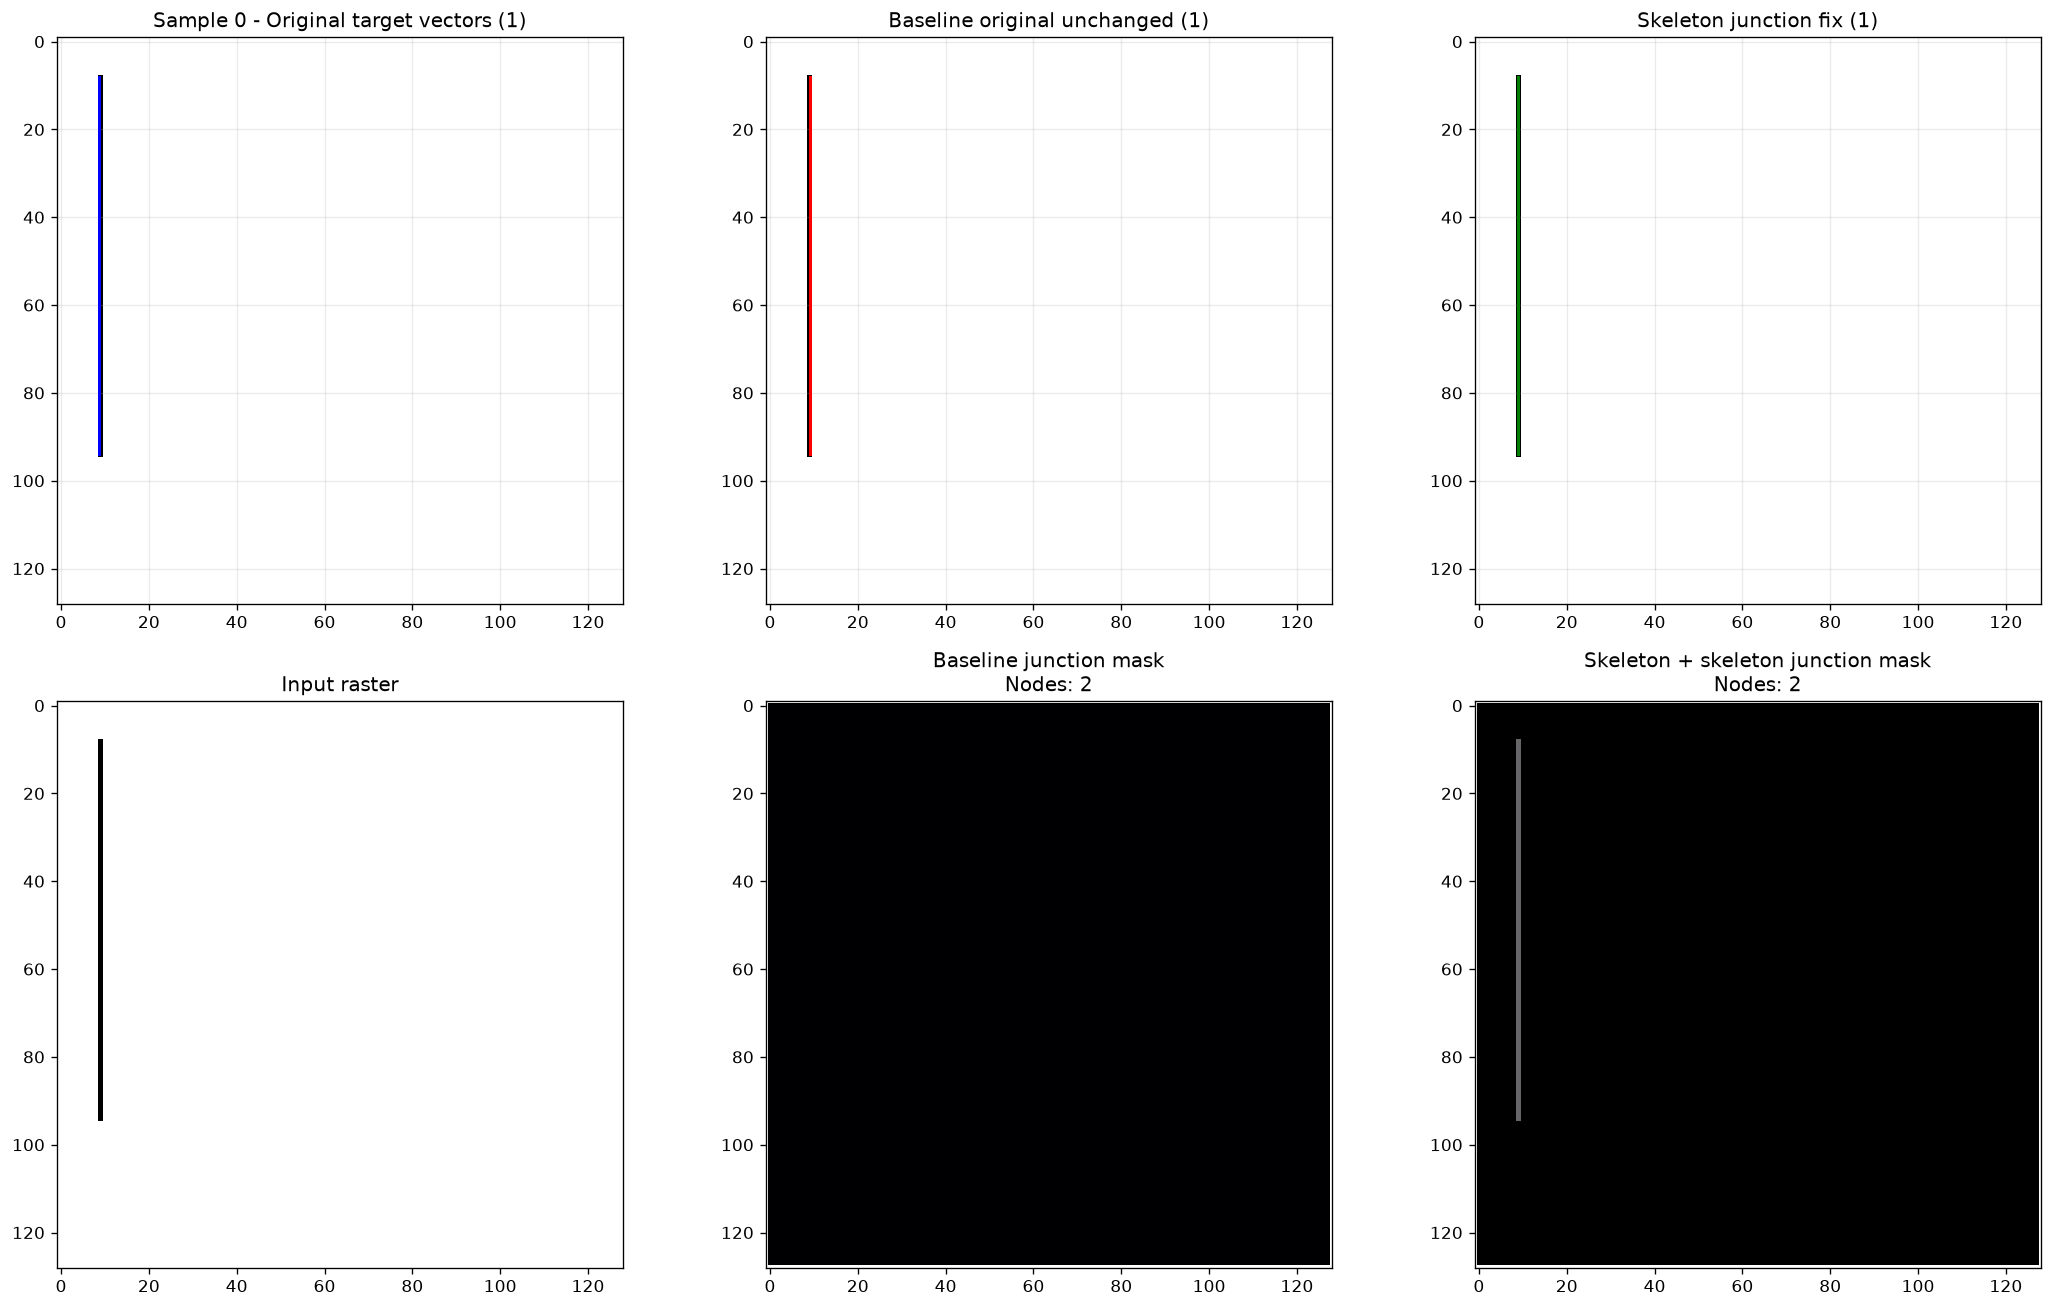

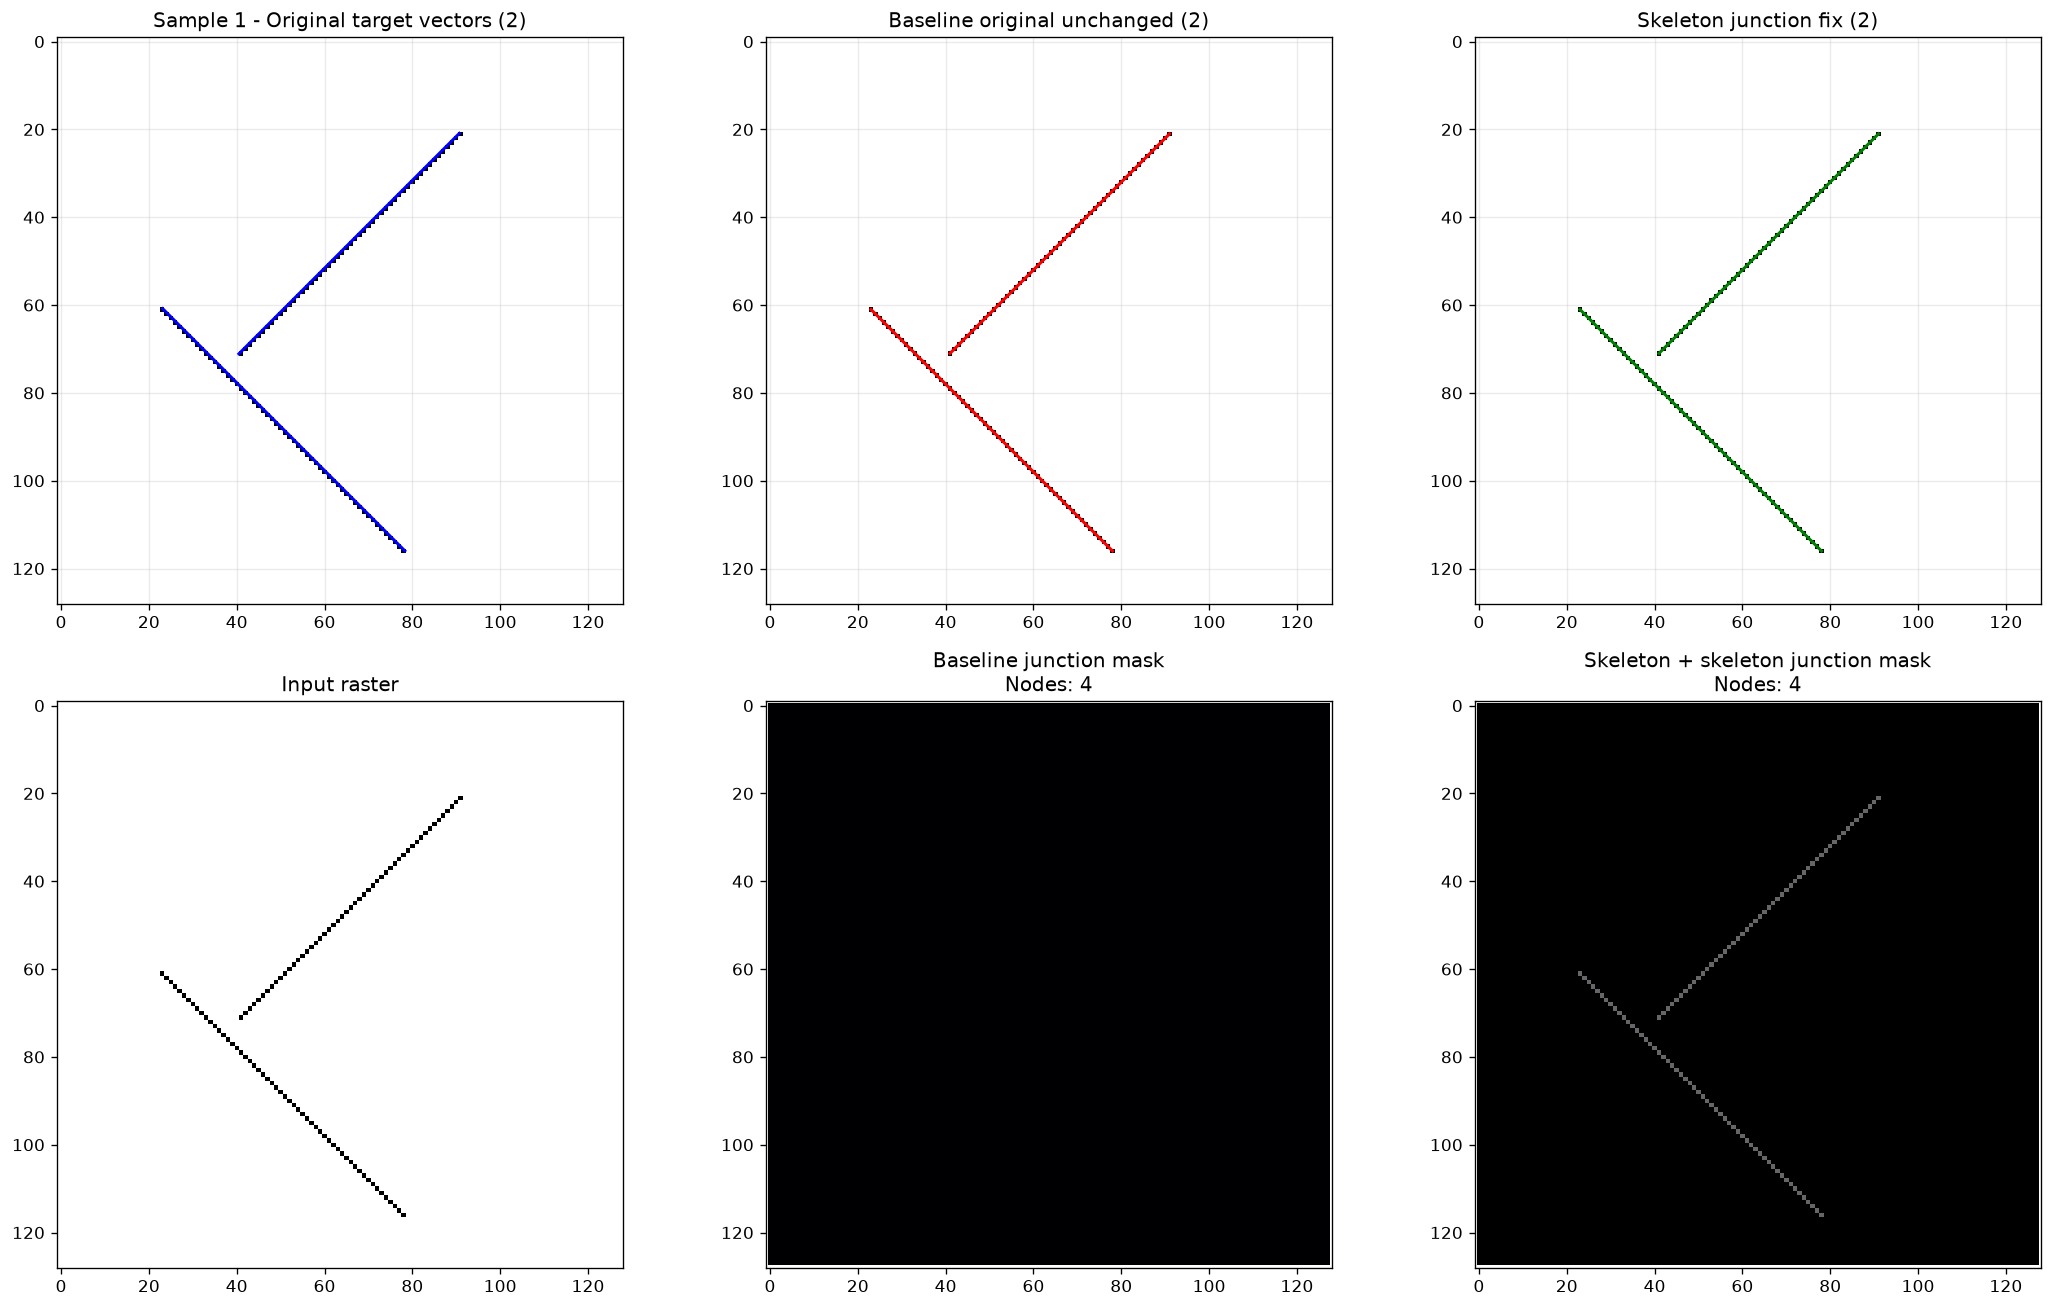

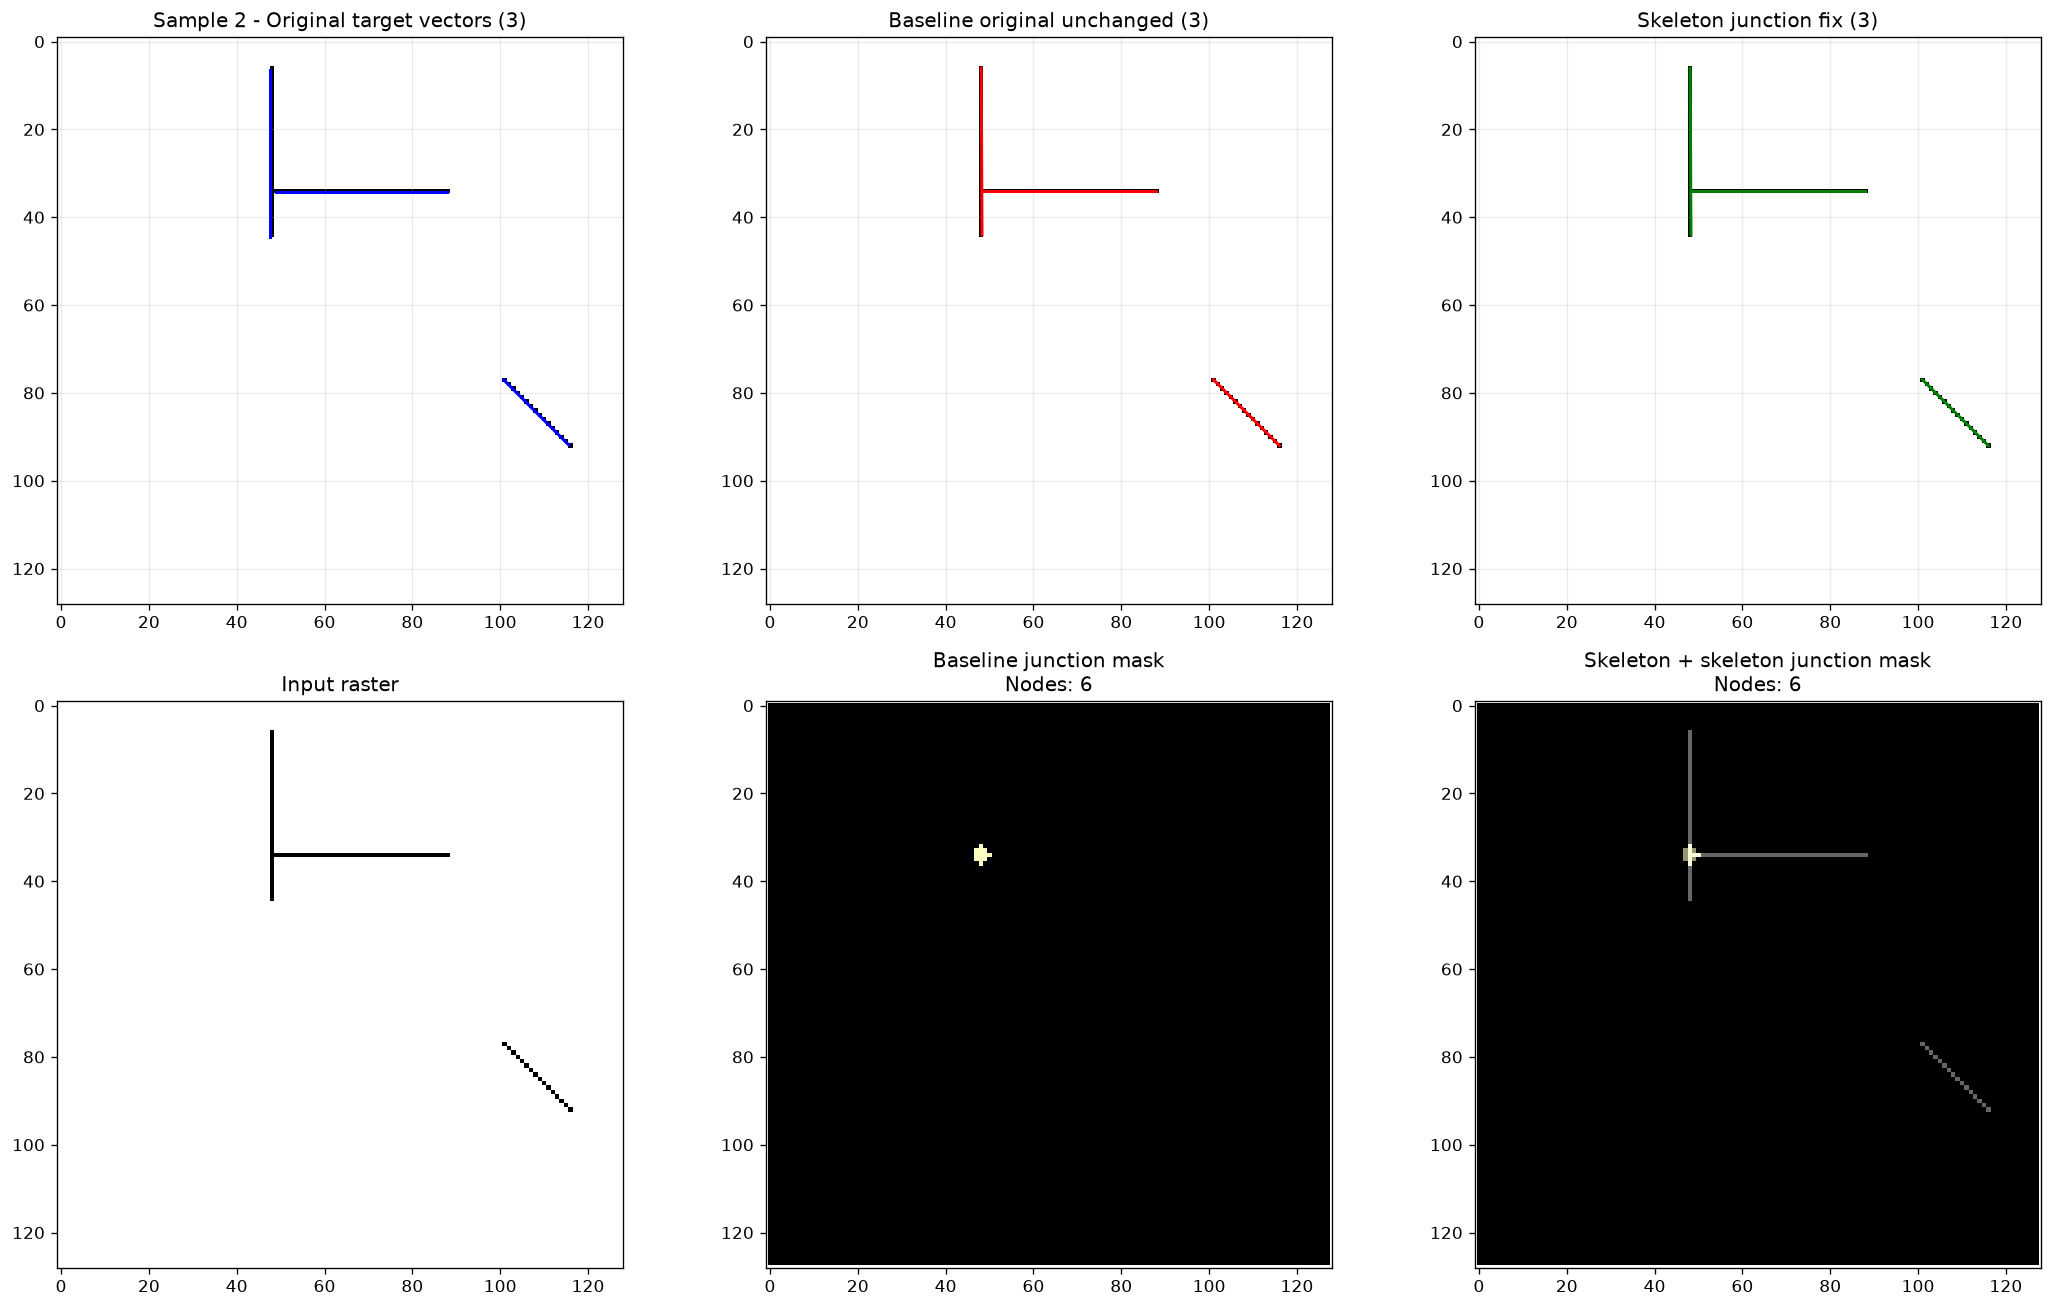

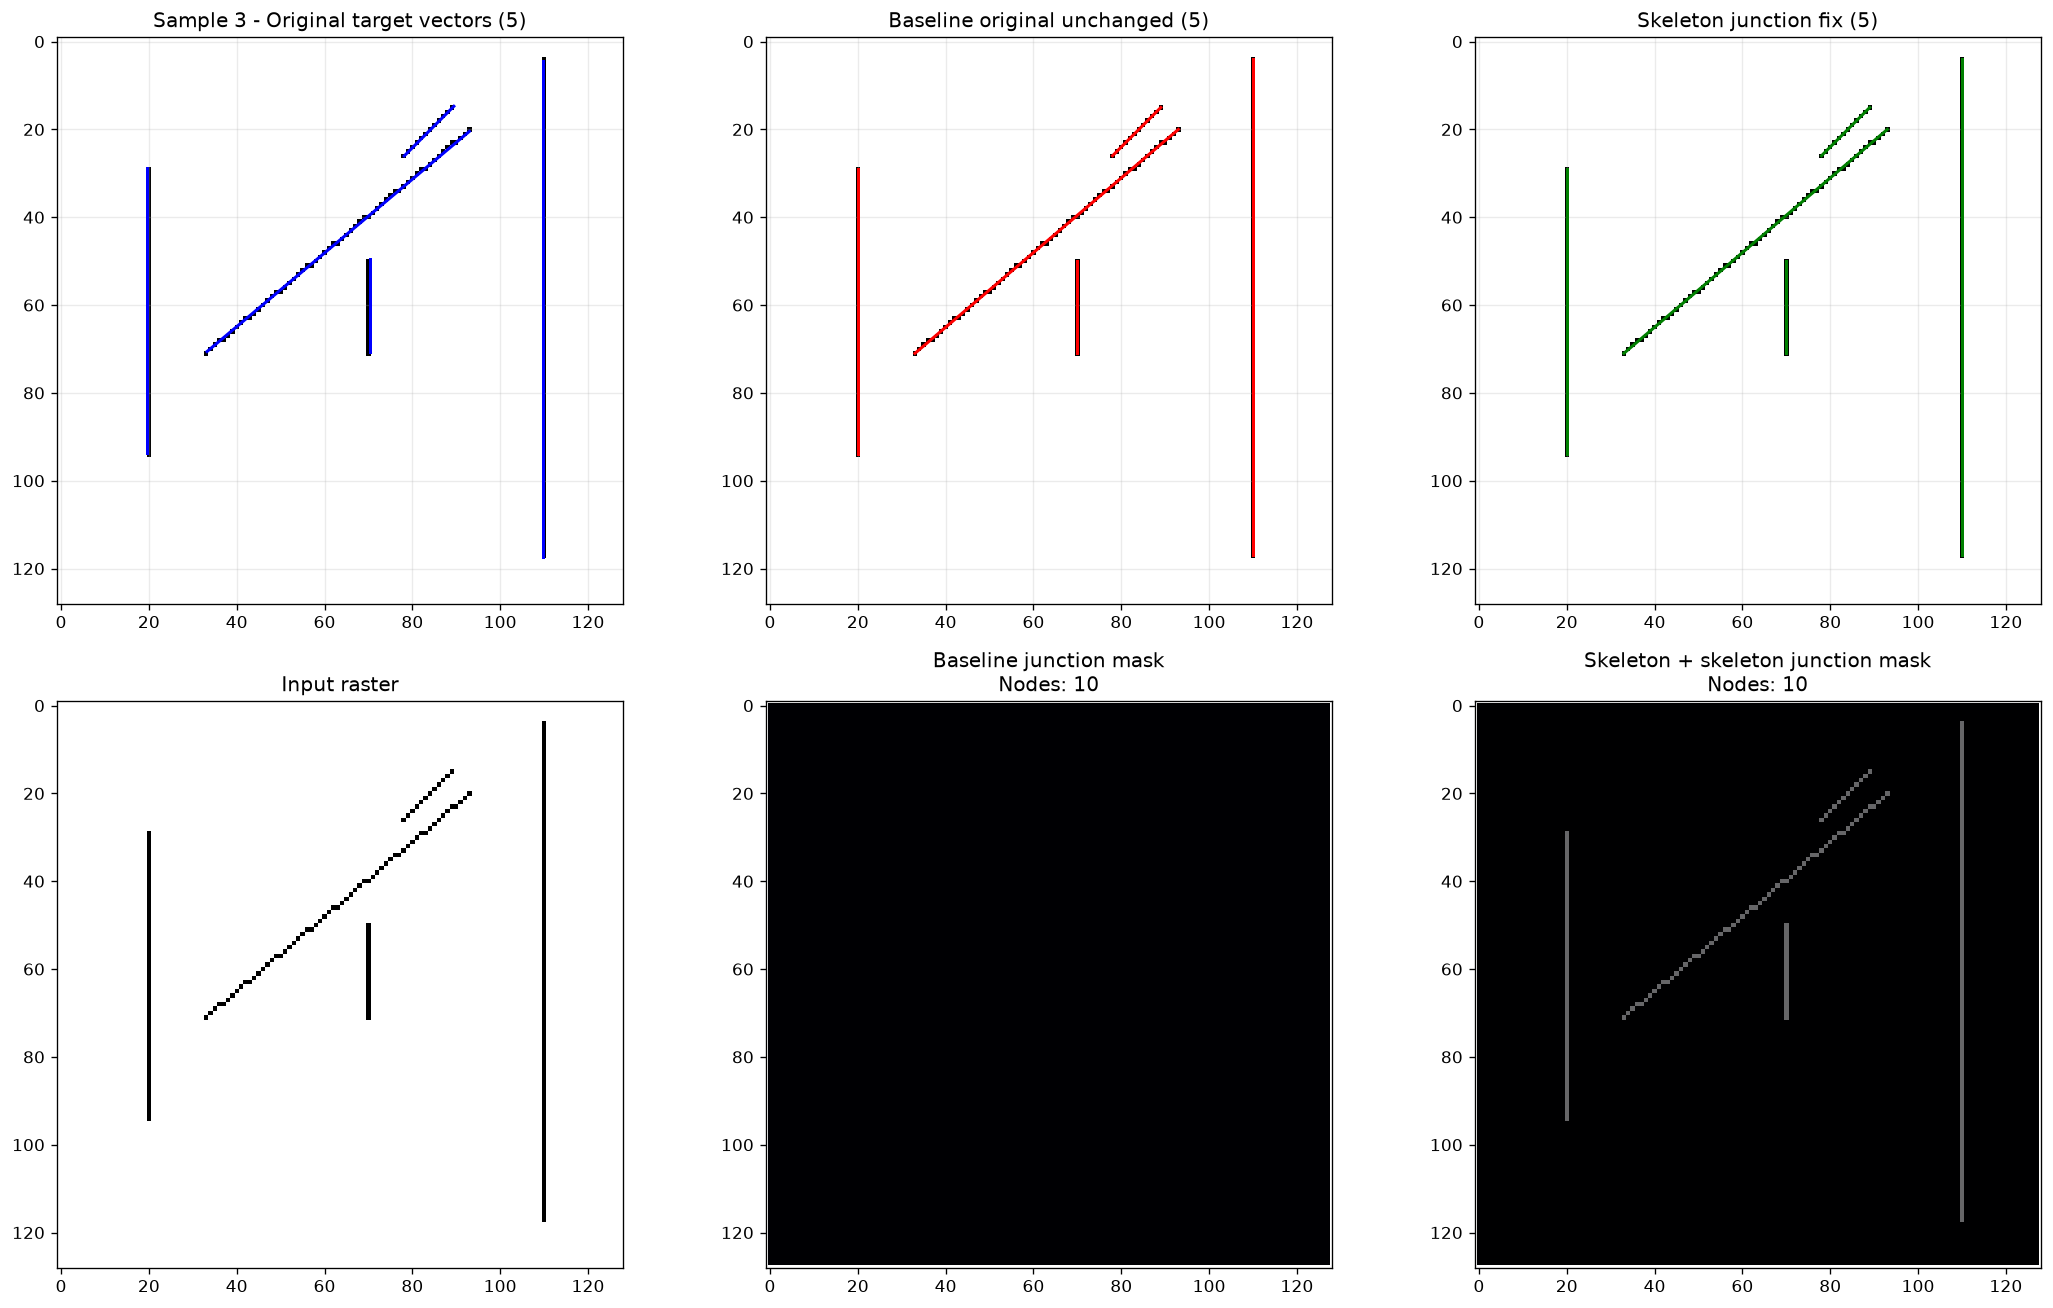

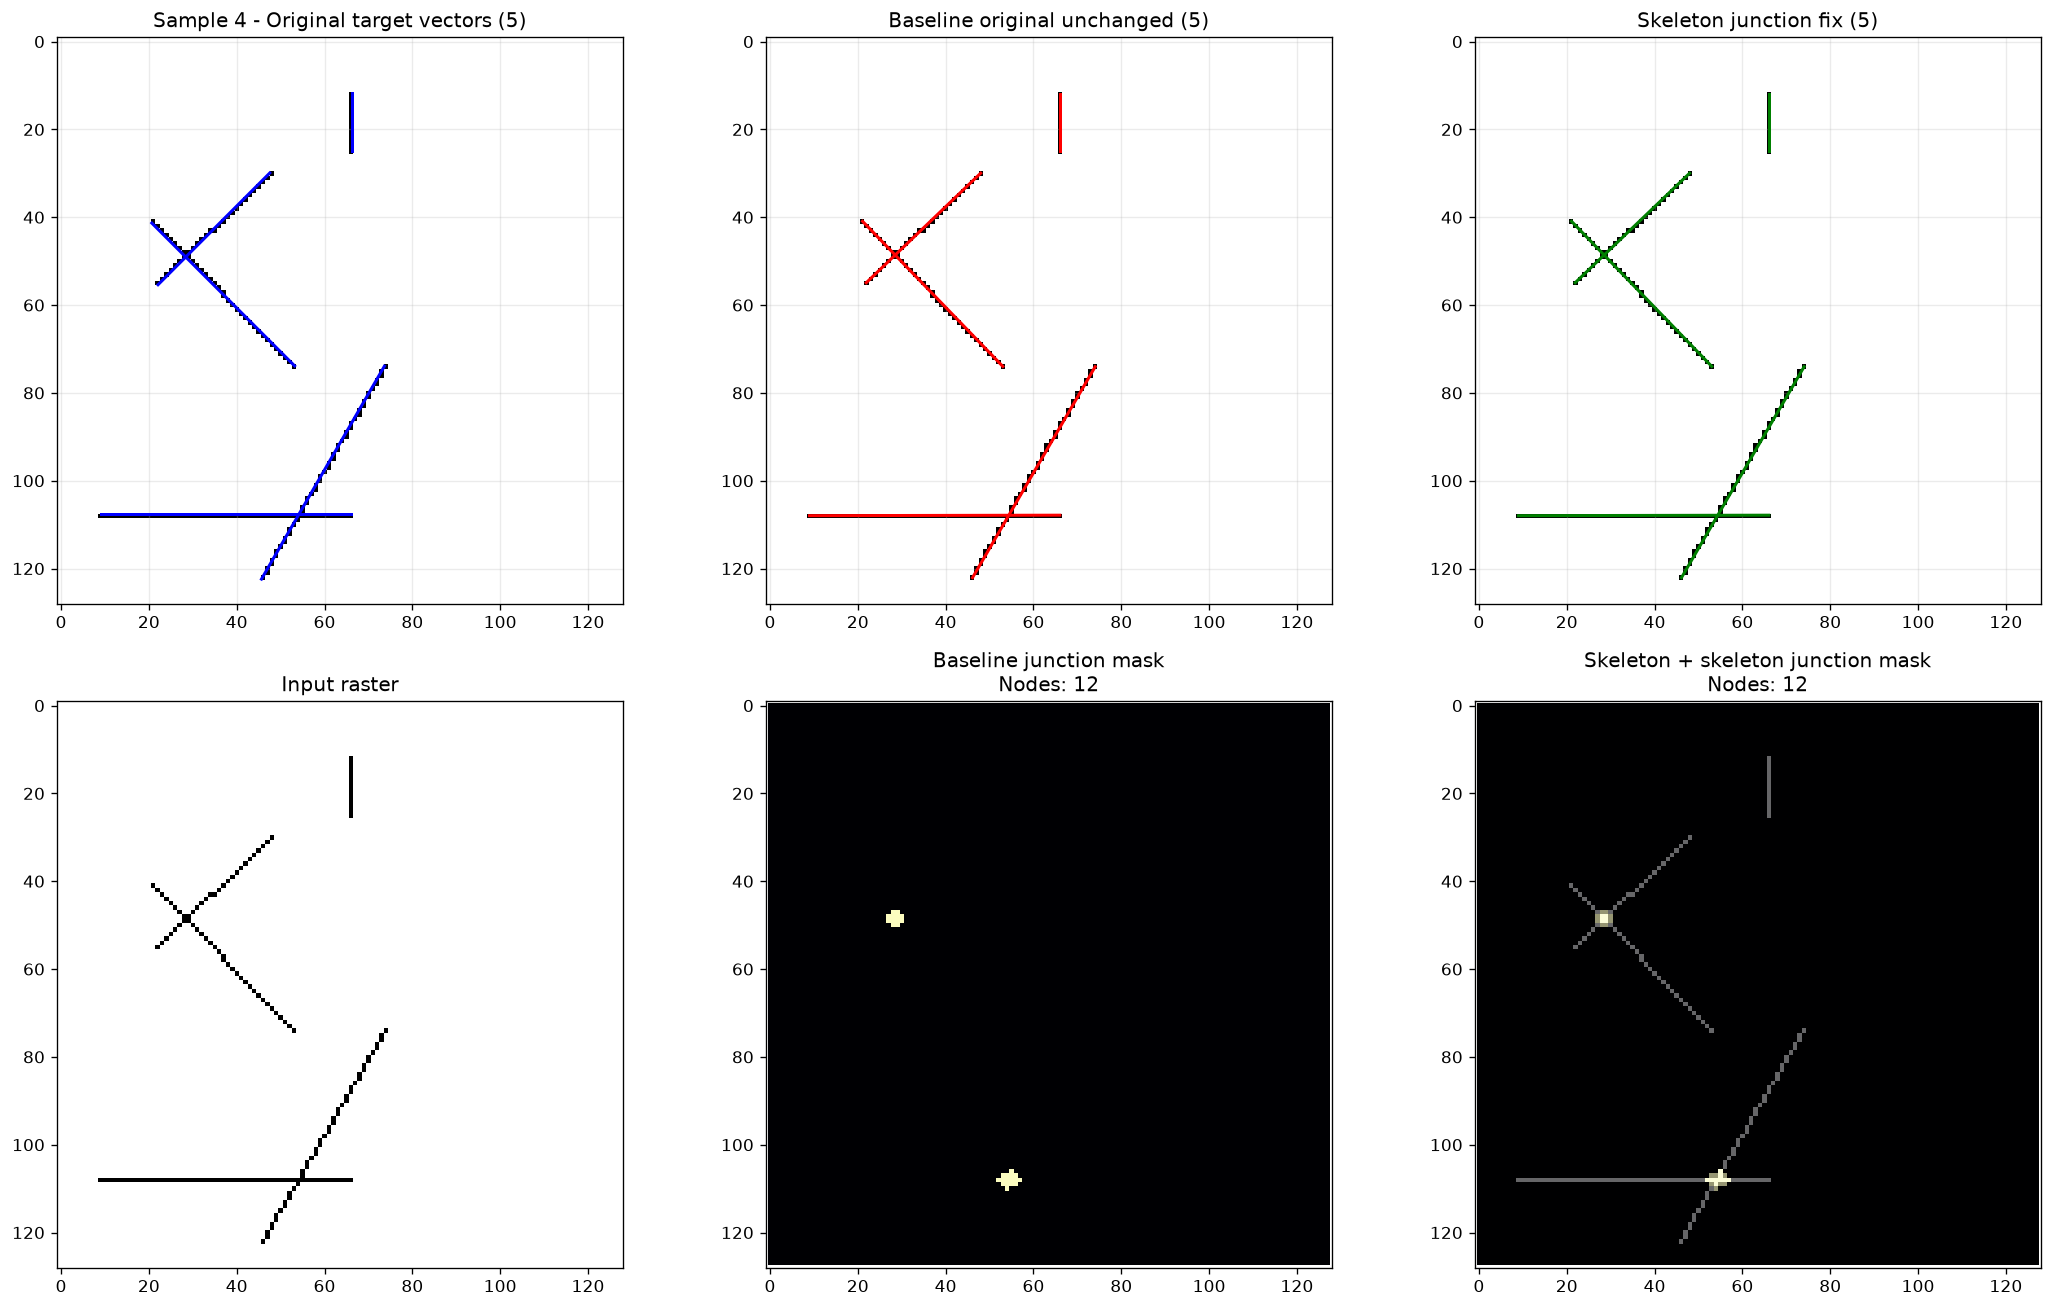

In [12]:
def draw_vectors(ax, image, vectors, title, colour='red'):
    ax.imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    for x0, y0, x1, y1 in vectors:
        ax.plot([x0, x1], [y0, y1], color=colour, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlim(-1, IMG_SIZE)
    ax.set_ylim(IMG_SIZE, -1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)


NUM_PREVIEWS = 5          # Change this to 1, 3, 10, 20, etc.
START_SAMPLE_INDEX = 0    # First sample to preview

# Use this instead if you want exact sample numbers.
# Example: SAMPLE_INDICES = [0, 4, 12, 20]
SAMPLE_INDICES = None


def show_baseline_vs_skeleton(sample_idx=0):
    image = test_images[sample_idx]
    original_vectors = test_vectors[sample_idx]

    base = comparison_outputs[sample_idx]['baseline_original_unchanged']
    skel = comparison_outputs[sample_idx]['skeleton_junction_fix']

    fig, ax = plt.subplots(2, 3, figsize=(18, 11), dpi=120)

    draw_vectors(
        ax[0, 0],
        image,
        original_vectors,
        f'Sample {sample_idx} - Original target vectors ({len(original_vectors)})',
        'blue'
    )

    draw_vectors(
        ax[0, 1],
        image,
        base['vectors'],
        f'Baseline original unchanged ({len(base["vectors"])})',
        'red'
    )

    draw_vectors(
        ax[0, 2],
        image,
        skel['vectors'],
        f'Skeleton junction fix ({len(skel["vectors"])})',
        'green'
    )

    ax[1, 0].imshow(image, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
    ax[1, 0].set_title('Input raster')

    ax[1, 1].imshow(base['debug']['junction_mask'], cmap='magma', interpolation='nearest')
    ax[1, 1].set_title(
        f'Baseline junction mask\nNodes: {len(base["debug"]["nodes"])}'
    )

    ax[1, 2].imshow(skel['debug']['skeleton'], cmap='gray', interpolation='nearest')
    ax[1, 2].imshow(
        skel['debug']['junction_mask'],
        cmap='magma',
        alpha=0.6,
        interpolation='nearest'
    )
    ax[1, 2].set_title(
        f'Skeleton + skeleton junction mask\nNodes: {len(skel["debug"]["nodes"])}'
    )

    for a in ax.ravel():
        a.set_xlim(-1, IMG_SIZE)
        a.set_ylim(IMG_SIZE, -1)
        a.set_aspect('equal')

    plt.tight_layout()
    plt.show()


def show_multiple_baseline_vs_skeleton(
    num_previews=5,
    start_sample_index=0,
    sample_indices=None
):
    if sample_indices is None:
        sample_indices = range(
            start_sample_index,
            start_sample_index + num_previews
        )
    else:
        sample_indices = list(sample_indices)

    for sample_idx in sample_indices:
        show_baseline_vs_skeleton(sample_idx)


show_multiple_baseline_vs_skeleton(
    num_previews=NUM_PREVIEWS,
    start_sample_index=START_SAMPLE_INDEX,
    sample_indices=SAMPLE_INDICES
)

## Layered SVG export

In [11]:
import re
import xml.etree.ElementTree as ET

SVG_NS = 'http://www.w3.org/2000/svg'
INKSCAPE_NS = 'http://www.inkscape.org/namespaces/inkscape'
ET.register_namespace('', SVG_NS)
ET.register_namespace('inkscape', INKSCAPE_NS)

LAYER_COLOURS = {
    'Original target vectors': '#1f77b4',
    'Baseline original unchanged': '#d62728',
    'Skeleton junction fix': '#2ca02c',
}


def safe_layer_id(name):
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', name).strip('_').lower()


def add_line_layer(svg, layer_name, vectors, colour, stroke_width=1.0, visible=True):
    layer = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
        'id': safe_layer_id(layer_name),
        f'{{{INKSCAPE_NS}}}groupmode': 'layer',
        f'{{{INKSCAPE_NS}}}label': layer_name,
        'stroke': colour,
        'stroke-width': str(stroke_width),
        'fill': 'none',
        'stroke-linecap': 'round',
        'stroke-linejoin': 'round',
        'style': 'display:inline' if visible else 'display:none',
    })
    ET.SubElement(layer, f'{{{SVG_NS}}}title').text = layer_name
    for x0, y0, x1, y1 in vectors:
        ET.SubElement(layer, f'{{{SVG_NS}}}line', {
            'x1': f'{x0:.3f}', 'y1': f'{y0:.3f}',
            'x2': f'{x1:.3f}', 'y2': f'{y1:.3f}',
        })
    return layer


def export_baseline_vs_skeleton_svg(sample_idx=0, filename=None, include_background=True):
    if filename is None:
        filename = EXPORT_DIR / f'sample_{sample_idx}_baseline_original_vs_skeleton_junction_fix.svg'

    scale = 6
    svg = ET.Element(f'{{{SVG_NS}}}svg', {
        'width': str(IMG_SIZE * scale),
        'height': str(IMG_SIZE * scale),
        'viewBox': f'0 0 {IMG_SIZE} {IMG_SIZE}',
        'version': '1.1',
    })

    if include_background:
        background = ET.SubElement(svg, f'{{{SVG_NS}}}g', {
            'id': 'background',
            f'{{{INKSCAPE_NS}}}groupmode': 'layer',
            f'{{{INKSCAPE_NS}}}label': 'Background',
            'style': 'display:inline',
        })
        ET.SubElement(background, f'{{{SVG_NS}}}rect', {
            'x': '0', 'y': '0',
            'width': str(IMG_SIZE), 'height': str(IMG_SIZE),
            'fill': 'white',
        })

    add_line_layer(svg, 'Original target vectors', test_vectors[sample_idx], LAYER_COLOURS['Original target vectors'], stroke_width=1.3)
    add_line_layer(svg, 'Baseline original unchanged', comparison_outputs[sample_idx]['baseline_original_unchanged']['vectors'], LAYER_COLOURS['Baseline original unchanged'])
    add_line_layer(svg, 'Skeleton junction fix', comparison_outputs[sample_idx]['skeleton_junction_fix']['vectors'], LAYER_COLOURS['Skeleton junction fix'])

    filename = Path(filename)
    ET.ElementTree(svg).write(filename, encoding='utf-8', xml_declaration=True)
    print(f'Saved layered SVG: {filename}')
    return filename


NUM_OUTPUT_EXAMPLES = 5
SAMPLE_INDICES = None

if SAMPLE_INDICES is None:
    SAMPLE_INDICES = range(min(NUM_OUTPUT_EXAMPLES, len(test_images)))

exported_svgs = [export_baseline_vs_skeleton_svg(i) for i in SAMPLE_INDICES]
exported_svgs

Saved layered SVG: strict_skeleton_junction_exports\sample_0_baseline_original_vs_skeleton_junction_fix.svg
Saved layered SVG: strict_skeleton_junction_exports\sample_1_baseline_original_vs_skeleton_junction_fix.svg
Saved layered SVG: strict_skeleton_junction_exports\sample_2_baseline_original_vs_skeleton_junction_fix.svg
Saved layered SVG: strict_skeleton_junction_exports\sample_3_baseline_original_vs_skeleton_junction_fix.svg
Saved layered SVG: strict_skeleton_junction_exports\sample_4_baseline_original_vs_skeleton_junction_fix.svg


[WindowsPath('strict_skeleton_junction_exports/sample_0_baseline_original_vs_skeleton_junction_fix.svg'),
 WindowsPath('strict_skeleton_junction_exports/sample_1_baseline_original_vs_skeleton_junction_fix.svg'),
 WindowsPath('strict_skeleton_junction_exports/sample_2_baseline_original_vs_skeleton_junction_fix.svg'),
 WindowsPath('strict_skeleton_junction_exports/sample_3_baseline_original_vs_skeleton_junction_fix.svg'),
 WindowsPath('strict_skeleton_junction_exports/sample_4_baseline_original_vs_skeleton_junction_fix.svg')]